In [27]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
from unidecode import unidecode
import matplotlib.pyplot as plt

import geopandas as gpd
import forestplot as fp

In [3]:
# load data
rais = pd.read_csv("final_project_data/rais_job_district_count.csv")
rais

,ano,id_municipio,distritos_sp,bairros_sp,total_empregos
0,2021,3550308,89.0,NaN,13024
1,2021,3550308,9.0,21.0,37745
2,2021,3550308,36.0,NaN,21746
3,2021,3550308,38.0,1737.0,180
4,2021,3550308,46.0,11.0,4402
...,...,...,...,...,...
3060,2021,3550308,NaN,1443.0,0
3061,2021,3550308,48.0,NaN,0
3062,2021,3550308,96.0,890.0,0
3063,2021,3550308,28.0,1623.0,0


In [9]:
ibge = pd.read_csv("final_project_data/Agregados_por_setores_basico_BR.csv", encoding="latin1", sep=";", quotechar='"', decimal=",")
ibge_sp = ibge[ibge.CD_MUN == 3550308]
ibge_sp.head()

,CD_SETOR,SITUACAO,CD_SIT,CD_TIPO,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,...,NM_CONCURB,v0001,v0002,v0003,v0004,v0005,v0006,v0007,v0008,v0009
331734,355030801000001,Urbana,1,0,0.071797,3,Sudeste,35,São Paulo,3550308,...,São Paulo/SP,682,329,329,0,2.4,0.0381,289,2,38
331735,355030801000002,Urbana,1,0,0.071902,3,Sudeste,35,São Paulo,3550308,...,São Paulo/SP,1374,1011,1011,0,2.3,0.0150,599,11,401
331736,355030801000003,Urbana,1,0,0.055681,3,Sudeste,35,São Paulo,3550308,...,São Paulo/SP,557,239,238,1,2.7,0.0927,205,0,33
331737,355030801000004,Urbana,1,0,0.064905,3,Sudeste,35,São Paulo,3550308,...,São Paulo/SP,526,245,245,0,2.4,0.0136,221,0,24
331738,355030801000005,Urbana,1,0,0.086822,3,Sudeste,35,São Paulo,3550308,...,São Paulo/SP,579,258,258,0,2.6,0.0905,221,0,37


In [6]:
od = pd.read_spss("final_project_data/OD_2017_v1.sav")
od_sp = od[od.muni_dom == "São Paulo"]
od_sp

,zona,muni_dom,co_dom_x,co_dom_y,id_dom,f_dom,fe_dom,dom,cd_entre,data,...,modoprin,tipvg,pag_viag,tp_esauto,vl_est,pe_bici,via_bici,tp_esbici,distancia,id_ordem
0,1.0,São Paulo,333743.0,7394463.0,00010001,Primeiro registro do domicílio,15.416667,1.0,Completo com viagem,06092017,...,A pé,A pé,NaN,NaN,NaN,Pequena distância,NaN,NaN,639.132224,1.0
1,1.0,São Paulo,333743.0,7394463.0,00010001,Demais registros,15.416667,1.0,Completo com viagem,06092017,...,A pé,A pé,NaN,NaN,NaN,Pequena distância,NaN,NaN,639.132224,2.0
2,1.0,São Paulo,333743.0,7394463.0,00010001,Demais registros,15.416667,1.0,Completo com viagem,06092017,...,Metrô,Coletivo,Empregador,NaN,NaN,NaN,NaN,NaN,6651.767885,3.0
3,1.0,São Paulo,333743.0,7394463.0,00010001,Demais registros,15.416667,1.0,Completo com viagem,06092017,...,Metrô,Coletivo,Empregador,NaN,NaN,NaN,NaN,NaN,4243.298717,4.0
4,1.0,São Paulo,333743.0,7394463.0,00010001,Demais registros,15.416667,1.0,Completo com viagem,06092017,...,Táxi não convencional,Individual,NaN,NaN,NaN,NaN,NaN,NaN,4557.622187,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126018,342.0,São Paulo,322857.0,7390956.0,03422006,Demais registros,128.603912,2006.0,Completo com viagem,18082018,...,Dirigindo automóvel,Individual,NaN,Próprio,NaN,NaN,NaN,NaN,1160.879408,126019.0
126019,342.0,São Paulo,323034.0,7390476.0,03422109,Primeiro registro do domicílio,128.603912,2109.0,Completo com viagem,16092018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126020.0
126020,342.0,São Paulo,323034.0,7390476.0,03422109,Demais registros,128.603912,2109.0,Completo com viagem,16092018,...,Ônibus/micro-ônibus/perua do município de São ...,Coletivo,Empregador,NaN,NaN,NaN,NaN,NaN,4644.921528,126021.0
126021,342.0,São Paulo,323034.0,7390476.0,03422109,Demais registros,128.603912,2109.0,Completo com viagem,16092018,...,Ônibus/micro-ônibus/perua do município de São ...,Coletivo,Isento,NaN,NaN,NaN,NaN,NaN,7012.886709,126022.0


In [33]:
zone_crosswalk = pd.read_excel("final_project_data/Corresp2017_2023_190225.xlsx",sheet_name="Divisão Administrativa",header=5,usecols="A:G")
zone_crosswalk.columns = ["zona_num", "zona_nome", "muni_num", "muni_nome", "distrito_num", "distrito_nome", "area_ha"]
zone_crosswalk

,zona_num,zona_nome,muni_num,muni_nome,distrito_num,distrito_nome,area_ha
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10
2,2.0,Parque Dom Pedro,36.0,São Paulo,80.0,Sé,113.64
3,3.0,Praça João Mendes,36.0,São Paulo,80.0,Sé,47.75
4,4.0,Ladeira da Memória,36.0,São Paulo,67.0,República,75.11
...,...,...,...,...,...,...,...
525,525.0,Amador Bueno,17.0,Itapevi,113.0,Itapevi,5113.23
526,526.0,Santana de Parnaíba,31.0,Santana de Parnaíba,127.0,Santana de Parnaíba,18034.76
527,527.0,Pirapora do Bom Jesus,25.0,Pirapora do Bom Jesus,121.0,Pirapora do Bom Jesus,10876.89
528,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def normalize(text):
    return unidecode(str(text)).upper().strip()

ibge_sp["NM_DIST_clean"] = ibge_sp["NM_DIST"].apply(normalize)
zone_crosswalk_sp["dist_name_clean"] = zone_crosswalk["distrito_nome"].apply(normalize)
zone_crosswalk_sp

,zona_num,zona_nome,muni_num,muni_nome,distrito_num,distrito_nome,area_ha,dist_name_clean
1,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE
2,2.0,Parque Dom Pedro,36.0,São Paulo,80.0,Sé,113.64,SE
3,3.0,Praça João Mendes,36.0,São Paulo,80.0,Sé,47.75,SE
4,4.0,Ladeira da Memória,36.0,São Paulo,67.0,República,75.11,REPUBLICA
5,5.0,República,36.0,São Paulo,67.0,República,74.95,REPUBLICA
...,...,...,...,...,...,...,...,...
338,338.0,Jaguaré,36.0,São Paulo,40.0,Jaguaré,430.44,JAGUARE
339,339.0,Cidade Universitária,36.0,São Paulo,12.0,Butantã,584.56,BUTANTA
340,340.0,Butantã,36.0,São Paulo,12.0,Butantã,207.11,BUTANTA
341,341.0,Jardim Caxingui,36.0,São Paulo,12.0,Butantã,180.08,BUTANTA


In [18]:
rais["distrito_clean"] = rais["distritos_sp"].apply(normalize)
zone_crosswalk_sp["dist_name_clean"] = zone_crosswalk["distrito_nome"].apply(normalize)
zone_crosswalk_sp

,zona_num,zona_nome,muni_num,muni_nome,distrito_num,distrito_nome,area_ha,dist_name_clean
1,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE
2,2.0,Parque Dom Pedro,36.0,São Paulo,80.0,Sé,113.64,SE
3,3.0,Praça João Mendes,36.0,São Paulo,80.0,Sé,47.75,SE
4,4.0,Ladeira da Memória,36.0,São Paulo,67.0,República,75.11,REPUBLICA
5,5.0,República,36.0,São Paulo,67.0,República,74.95,REPUBLICA
...,...,...,...,...,...,...,...,...
338,338.0,Jaguaré,36.0,São Paulo,40.0,Jaguaré,430.44,JAGUARE
339,339.0,Cidade Universitária,36.0,São Paulo,12.0,Butantã,584.56,BUTANTA
340,340.0,Butantã,36.0,São Paulo,12.0,Butantã,207.11,BUTANTA
341,341.0,Jardim Caxingui,36.0,São Paulo,12.0,Butantã,180.08,BUTANTA


In [21]:
rais_zone = zone_crosswalk_sp.merge(rais, left_on="distrito_num", right_on="distritos_sp", how="left")
rais_zone

,zona_num,zona_nome,muni_num,muni_nome,distrito_num,distrito_nome,area_ha,dist_name_clean,ano,id_municipio,distritos_sp,bairros_sp,total_empregos,distrito_clean
0,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,99.0,170685,80.0
1,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,1316.0,2608,80.0
2,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,64.0,1509,80.0
3,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,22.0,0,80.0
4,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,1285.0,25856,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,473.0,31,12.0
10254,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,98.0,5101,12.0
10255,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,343.0,6166,12.0
10256,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,1086.0,2393,12.0


In [22]:
rais_zone["n_zones_in_dist"] = rais_zone.groupby("distrito_num")["zona_num"].transform("count")
rais_zone["jobs_allocated"] = rais_zone["total_empregos"] / rais_zone["n_zones_in_dist"]
rais_zone

,zona_num,zona_nome,muni_num,muni_nome,distrito_num,distrito_nome,area_ha,dist_name_clean,ano,id_municipio,distritos_sp,bairros_sp,total_empregos,distrito_clean,n_zones_in_dist,jobs_allocated
0,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,99.0,170685,80.0,39,4376.538462
1,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,1316.0,2608,80.0,39,66.871795
2,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,64.0,1509,80.0,39,38.692308
3,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,22.0,0,80.0,39,0.000000
4,1.0,Sé,36.0,São Paulo,80.0,Sé,57.10,SE,2021,3550308,80.0,1285.0,25856,80.0,39,662.974359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10253,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,473.0,31,12.0,72,0.430556
10254,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,98.0,5101,12.0,72,70.847222
10255,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,343.0,6166,12.0,72,85.638889
10256,342.0,Jardim Bonfiglioli,36.0,São Paulo,12.0,Butantã,319.97,BUTANTA,2021,3550308,12.0,1086.0,2393,12.0,72,33.236111


In [174]:
jobs_by_zone = rais_zone.groupby("zona_num")["jobs_allocated"].sum().reset_index()
jobs_by_zone

,zona_num,jobs_allocated
0,1.0,5877.641026
1,2.0,5877.641026
2,3.0,5877.641026
3,4.0,281.000000
4,5.0,281.000000
...,...,...
337,338.0,201.000000
338,339.0,823.972222
339,340.0,823.972222
340,341.0,823.972222


In [23]:
household_by_dist = ibge_sp.groupby("NM_DIST_clean")["v0002"].sum().reset_index()
household_by_dist.columns = ["dist_name_clean", "total_household"]
household_by_dist

,dist_name_clean,total_household
0,AGUA RASA,41161
1,ALTO DE PINHEIROS,17931
2,ANHANGUERA,30340
3,ARICANDUVA,37225
4,ARTUR ALVIM,40976
...,...,...
91,VILA MARIANA,70691
92,VILA MATILDE,45322
93,VILA MEDEIROS,48273
94,VILA PRUDENTE,49782


In [210]:
ibge_zone = zone_crosswalk_sp.merge(household_by_dist, on="dist_name_clean", how="left")

In [24]:
ibge_zone["n_zones_in_dist"] = ibge_zone.groupby("distrito_num")["zona_num"].transform("count")
ibge_zone["households_allocated"] = ibge_zone["total_household"] / ibge_zone["n_zones_in_dist"]
ibge_zone

NameError: name 'ibge_zone' is not defined

In [213]:
households_by_zone = ibge_zone.groupby("zona_num")["households_allocated"].sum().reset_index()
households_by_zone

,zona_num,households_allocated
0,1.0,4628.333333
1,2.0,4628.333333
2,3.0,4628.333333
3,4.0,14299.666667
4,5.0,14299.666667
...,...,...
337,338.0,11808.500000
338,339.0,6496.000000
339,340.0,6496.000000
340,341.0,6496.000000


In [214]:
job_housing = jobs_by_zone.merge(households_by_zone, on="zona_num", how="outer")
job_housing["job_housing_ratio"] = job_housing["jobs_allocated"] / job_housing["households_allocated"]
job_housing

,zona_num,jobs_allocated,households_allocated,job_housing_ratio
0,1.0,5877.641026,4628.333333,1.269926
1,2.0,5877.641026,4628.333333,1.269926
2,3.0,5877.641026,4628.333333,1.269926
3,4.0,281.000000,14299.666667,0.019651
4,5.0,281.000000,14299.666667,0.019651
...,...,...,...,...
337,338.0,201.000000,11808.500000,0.017022
338,339.0,823.972222,6496.000000,0.126843
339,340.0,823.972222,6496.000000,0.126843
340,341.0,823.972222,6496.000000,0.126843


In [235]:
time_by_zone = od_sp.groupby("zona")["duracao"].sum().reset_index()
time_by_zone["hours"] = time_by_zone["duracao"] / 60
time_by_zone["distrito_num"] = 

,zona,duracao,hours
0,1.0,5592.0,93.200000
1,2.0,4995.0,83.250000
2,3.0,5451.0,90.850000
3,4.0,7470.0,124.500000
4,5.0,3854.0,64.233333
...,...,...,...
324,337.0,7781.0,129.683333
325,338.0,9476.0,157.933333
326,340.0,15031.0,250.516667
327,341.0,7918.0,131.966667


In [234]:
job_access_time = job_housing.merge(time_by_zone, left_on="zona_num", right_on="zona", how="left")
job_access_time

,zona_num,jobs_allocated,households_allocated,job_housing_ratio,zona,duracao,hours
0,1.0,5877.641026,4628.333333,1.269926,1.0,5592.0,93.200000
1,2.0,5877.641026,4628.333333,1.269926,2.0,4995.0,83.250000
2,3.0,5877.641026,4628.333333,1.269926,3.0,5451.0,90.850000
3,4.0,281.000000,14299.666667,0.019651,4.0,7470.0,124.500000
4,5.0,281.000000,14299.666667,0.019651,5.0,3854.0,64.233333
...,...,...,...,...,...,...,...
337,338.0,201.000000,11808.500000,0.017022,338.0,9476.0,157.933333
338,339.0,823.972222,6496.000000,0.126843,NaN,NaN,NaN
339,340.0,823.972222,6496.000000,0.126843,340.0,15031.0,250.516667
340,341.0,823.972222,6496.000000,0.126843,341.0,7918.0,131.966667


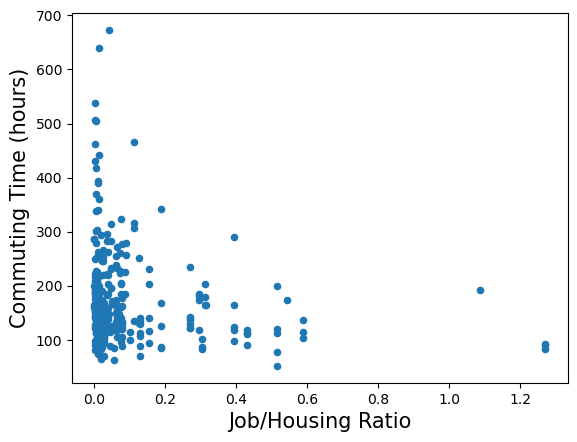

In [236]:
job_access_time.plot.scatter(x='job_housing_ratio', y='hours')
plt.xlabel("Job/Housing Ratio", fontsize=15)
plt.ylabel("Commuting Time (hours)", fontsize=15)
plt.show()

In [28]:
fp.forestplot(od_sp,  # the dataframe with results data
              estimate="r",  # col containing estimated effect size 
              ll="ll", hl="hl",  # columns containing conf. int. lower and higher limits
              varlabel="label",  # column containing variable label
              ylabel="Confidence interval",  # y-label title
              xlabel="Pearson correlation",  # x-label title
              )

KeyError: 'r'